In [1]:
# --- Cell 1: Install Dependencies ---
!pip install transformers datasets==3.6.0 rouge-score sentencepiece accelerate -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 38.1 MB/s eta 0:00:00


In [2]:
# --- Cell 3: Load Dataset ---
from datasets import load_dataset
import pandas as pd

print("Loading dataset PubMed dari Hugging Face...")
print("Ref: https://huggingface.co/datasets/armanc/scientific_papers")

# Load subset PubMed sesuai proposal
dataset = load_dataset("ccdv/pubmed-summarization")  # langsung, tanpa "pubmed"

print("\nDataset splits tersedia:")
print(dataset)

print(f"\nJumlah data:")
print(f"  Train      : {len(dataset['train']):,}")
print(f"  Validation : {len(dataset['validation']):,}")
print(f"  Test       : {len(dataset['test']):,}")

Loading dataset PubMed dari Hugging Face...
Ref: https://huggingface.co/datasets/armanc/scientific_papers


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]


Dataset splits tersedia:
DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})

Jumlah data:
  Train      : 119,924
  Validation : 6,633
  Test       : 6,658


In [3]:
# --- Cell 4: Lihat Contoh Data ---
sample = dataset['train'][0]
print("=== Contoh Data (Train[0]) ===")
print(f"\nKolom tersedia: {list(sample.keys())}")
# armanc/scientific_papers punya kolom: article, abstract, section_names
print(f"\nPanjang article : {len(sample['article'].split())} kata")
print(f"Panjang abstract: {len(sample['abstract'].split())} kata")
print(f"\n--- Article (200 karakter pertama) ---")
print(sample['article'][:200])
print(f"\n--- Abstract ---")
print(sample['abstract'][:300])

=== Contoh Data (Train[0]) ===

Kolom tersedia: ['article', 'abstract']

Panjang article : 4811 kata
Panjang abstract: 248 kata

--- Article (200 karakter pertama) ---
a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , mode

--- Abstract ---
background : the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school - aged children in shiraz , iran.materials and methods : this case - control nutritional intervention has been done between 2008 and


In [4]:
# --- Cell 5: Mapping Kolom ---
def map_columns(example):
    return {
        "input_text": example["article"],
        "target_text": example["abstract"]
    }

dataset = dataset.map(map_columns, remove_columns=["article", "abstract"])

print("Kolom setelah mapping:", dataset['train'].column_names)
print("Contoh input_text (50 kata pertama):")
print(" ".join(dataset['train'][0]['input_text'].split()[:50]))

Map:   0%|          | 0/119924 [00:00<?, ? examples/s]

Map:   0%|          | 0/6633 [00:00<?, ? examples/s]

Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Kolom setelah mapping: ['input_text', 'target_text']
Contoh input_text (50 kata pertama):
a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , moderately or severely underweight in the developing countries . in iran


In [5]:
# --- Cell 6: Konfigurasi Ukuran Dataset (Debug/Full) ---
# ============================================================
# SESUAI PROPOSAL: subset kecil untuk debugging pipeline dulu
# Ganti ke angka lebih besar saat full experiment
# ============================================================
DEBUG_MODE = True
DEBUG_SIZE = 6658   # jumlah sample untuk debug
EVAL_SIZE  = 500   # jumlah sample untuk evaluasi

if DEBUG_MODE:
    train_data = dataset['train'].select(range(DEBUG_SIZE))
    val_data   = dataset['validation'].select(range(EVAL_SIZE))
    test_data  = dataset['test'].select(range(EVAL_SIZE))
    print(f"[DEBUG MODE] Menggunakan subset kecil:")
else:
    train_data = dataset['train']
    val_data   = dataset['validation']
    test_data  = dataset['test']
    print(f"[FULL MODE] Menggunakan seluruh dataset:")

print(f"  Train : {len(train_data):,}")
print(f"  Val   : {len(val_data):,}")
print(f"  Test  : {len(test_data):,}")

[DEBUG MODE] Menggunakan subset kecil:
  Train : 6,658
  Val   : 500
  Test  : 500


In [6]:
# --- Cell 7: Simpan Dataset ke Disk ---
SAVE_PATH = "./scientific_papers_pubmed"
dataset.save_to_disk(SAVE_PATH)
print(f"Dataset disimpan ke: {SAVE_PATH}")
print("\nLoad ulang tanpa download:")
print("  from datasets import load_from_disk")
print(f"  dataset = load_from_disk('./scientific_papers_pubmed')")

Saving the dataset (0/5 shards):   0%|          | 0/119924 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6633 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6658 [00:00<?, ? examples/s]

Dataset disimpan ke: ./scientific_papers_pubmed

Load ulang tanpa download:
  from datasets import load_from_disk
  dataset = load_from_disk('./scientific_papers_pubmed')


In [7]:
# --- Cell 8: Fungsi Cleaning Teks ---
import re

def clean_text(text):
    """
    Cleaning & Normalization sesuai proposal:
    - Gabung kalimat jadi satu teks utuh
    - Hapus simbol tidak penting
    - Rapikan spasi/tab/newline
    """
    # Handle list of sentences (kalau input berupa list)
    if isinstance(text, list):
        text = " ".join(text)

    # Hapus karakter khusus yang tidak bermakna (bukan alfanumerik/punctuation ilmiah)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)

    # Normalisasi spasi, tab, newline berlebih
    text = re.sub(r'\s+', ' ', text)

    # Trim
    text = text.strip()

    return text

# Test cleaning
sample_raw = dataset['train'][0]['input_text']
sample_clean = clean_text(sample_raw)
print("Sebelum cleaning (50 karakter pertama):")
print(repr(sample_raw[:100]))
print("\nSetelah cleaning (50 karakter pertama):")
print(repr(sample_clean[:100]))

Sebelum cleaning (50 karakter pertama):
'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5'

Setelah cleaning (50 karakter pertama):
'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5'


In [8]:
# --- Cell 9: Load Tokenizer ---
from transformers import BartTokenizer

# Load tokenizer BART
MODEL_NAME = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)

# Parameter panjang token sesuai proposal (max_input_length, max_target_length)
# BART memiliki batas 1024 token — ini limitasi yang dicatat di proposal
MAX_INPUT_LENGTH  = 1024
MAX_TARGET_LENGTH = 256

print(f"Tokenizer: {MODEL_NAME}")
print(f"Max input length : {MAX_INPUT_LENGTH}")
print(f"Max target length: {MAX_TARGET_LENGTH}")
print(f"Vocab size       : {tokenizer.vocab_size:,}")

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer: facebook/bart-large-cnn
Max input length : 1024
Max target length: 256
Vocab size       : 50,265


In [9]:
# --- Cell 10: Apply Preprocessing & Tokenization ---
def preprocess(examples):
    # Cleaning → Normalization → Tokenization

    # Cleaning & Normalization
    inputs  = [clean_text(txt) for txt in examples["input_text"]]
    targets = [clean_text(txt) for txt in examples["target_text"]]

    # Tokenization input
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        padding="max_length",
        truncation=True
    )

    # Tokenization target
    labels = tokenizer(
       text_target=targets,
       max_length=MAX_TARGET_LENGTH,
       padding="max_length",
       truncation=True
    )

    # Set padding token jadi -100 agar tidak dihitung dalam loss
    labels_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs

# Apply preprocessing
print("Preprocessing train data...")
tokenized_train = train_data.map(preprocess, batched=True, remove_columns=train_data.column_names)
print("Preprocessing validation data...")
tokenized_val = val_data.map(preprocess, batched=True, remove_columns=val_data.column_names)
print("Preprocessing test data...")
tokenized_test = test_data.map(preprocess, batched=True, remove_columns=test_data.column_names)

print(f"\nSelesai! Kolom tokenized: {tokenized_train.column_names}")

Preprocessing train data...


Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Preprocessing validation data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Preprocessing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Selesai! Kolom tokenized: ['input_ids', 'attention_mask', 'labels']


In [10]:
# --- Cell 11: Load Model BART ---
from transformers import BartForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
import torch

# Load model BART
print(f"Loading model: {MODEL_NAME}")
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

# Cek device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Tidak ada GPU")

print(f"\nJumlah parameter model: {model.num_parameters():,}")

Loading model: facebook/bart-large-cnn


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB

Jumlah parameter model: 406,290,432


In [11]:
# --- Cell 12: Konfigurasi Training Arguments ---
# Konfigurasi Training Arguments sesuai proposal
training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-pubmed-results",

    # === Parameter utama sesuai proposal ===
    num_train_epochs=3,            # jumlah epoch
    learning_rate=5e-5,            # learning rate
    per_device_train_batch_size=2, # batch size (kecil karena BART besar)
    per_device_eval_batch_size=2,

    # === Seq2Seq spesifik ===
    predict_with_generate=True,    # generate saat evaluasi
    generation_max_length=MAX_TARGET_LENGTH,

    # === Logging & Saving ===
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
    save_total_limit=2,

    # === Efisiensi ===
    fp16=torch.cuda.is_available(),  # mixed precision kalau ada GPU
    gradient_accumulation_steps=4,   # simulasi batch lebih besar
    warmup_steps=100,
    weight_decay=0.01,
)

print("Training arguments configured:")
print(f"  Epochs         : {training_args.num_train_epochs}")
print(f"  Learning rate  : {training_args.learning_rate}")
print(f"  Batch size     : {training_args.per_device_train_batch_size}")
print(f"  FP16           : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured:
  Epochs         : 3
  Learning rate  : 5e-05
  Batch size     : 2
  FP16           : True


In [12]:
# --- Cell 13: Data Collator & Setup Trainer ---
# Data collator untuk seq2seq
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Setup Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,  # ✅ ganti dari tokenizer= ke processing_class=
    data_collator=data_collator,
)

print("Trainer siap!")
print(f"Total training steps: {len(tokenized_train) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")

Trainer siap!
Total training steps: 9987


In [13]:
# --- Cell 14: Jalankan Training ---
# ============================================================
# TRAINING
# dipantau menggunakan validation set
# ============================================================
print("Mulai training BART...")
print("="*50)

train_result = trainer.train()

print("\nTraining selesai!")
print(f"Training loss akhir: {train_result.training_loss:.4f}")
print(f"Total runtime      : {train_result.metrics['train_runtime']:.1f} detik")

Mulai training BART...


Epoch,Training Loss,Validation Loss
1,8.589507,2.131191
2,7.843151,2.057282
3,6.374179,2.059475


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



Training selesai!
Training loss akhir: 7.9933
Total runtime      : 1101.8 detik


In [14]:
# --- Cell 15: Simpan Model Lokal ---
# Simpan model fine-tuned
model.save_pretrained("./bart-pubmed-finetuned")
tokenizer.save_pretrained("./bart-pubmed-finetuned")
print("Model disimpan ke: ./bart-pubmed-finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model disimpan ke: ./bart-pubmed-finetuned


In [15]:
# --- Cell 16: Setup Model untuk Inference ---
from transformers import BartForConditionalGeneration, BartTokenizer

# Load model fine-tuned langsung (tanpa pipeline)
model_inf = BartForConditionalGeneration.from_pretrained("./bart-pubmed-finetuned")
tokenizer_inf = BartTokenizer.from_pretrained("./bart-pubmed-finetuned")
model_inf = model_inf.to(device)
model_inf.eval()

print("Model inferensi siap!")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Model inferensi siap!


In [16]:
# --- Cell 17: Fungsi Generate Summary ---
import torch

def generate_summary(text, max_length=256, min_length=50):
    inputs = tokenizer_inf(
        text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=3,
            num_beams=4,
            early_stopping=True
        )

    return tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)

# Test
sample = test_data[0]
print("--- Generated ---")
print(generate_summary(sample['input_text']))
print("\n--- Reference ---")
print(sample['target_text'])

--- Generated ---
backgroundanxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression . however , few studies have specifically investigated the relationship between anxiety and cognition in pd patients.objectivesthe aim of this study was to examine the effect of anxiety on cognition in patients with pd and without anxiety.materials and methodsthis was a cross - sectional study of thirty - three patients with idiopathic pd ( n = 17 ) and thirty - seven pd without anxiety . the neuropsychological status index ( rbans ) was used to assess cognitive performance in attentional set - shifting and working memory.resultsthere were no significant differences between pd with anxiety and patients without anxiety ( p < 0.05 ) in terms of the mean scores of attentional shift , working memory , and visuospatial functioning ( p = 0.01 ) , while there was no significant difference between the two g

In [17]:
# --- Cell 18: Generate Summary untuk Seluruh Test Set ---
# Generate ringkasan untuk seluruh test set
print("Generating ringkasan untuk semua data test...")

generated_summaries = []
reference_summaries = []

for i, sample in enumerate(test_data):
    gen = generate_summary(sample['input_text'])
    generated_summaries.append(gen)
    reference_summaries.append(sample['target_text'])

    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(test_data)}")

print(f"\nSelesai! Total ringkasan: {len(generated_summaries)}")

Generating ringkasan untuk semua data test...
  Progress: 20/500
  Progress: 40/500
  Progress: 60/500
  Progress: 80/500
  Progress: 100/500
  Progress: 120/500
  Progress: 140/500
  Progress: 160/500
  Progress: 180/500
  Progress: 200/500
  Progress: 220/500
  Progress: 240/500
  Progress: 260/500
  Progress: 280/500
  Progress: 300/500
  Progress: 320/500
  Progress: 340/500
  Progress: 360/500
  Progress: 380/500
  Progress: 400/500
  Progress: 420/500
  Progress: 440/500
  Progress: 460/500
  Progress: 480/500
  Progress: 500/500

Selesai! Total ringkasan: 500


In [18]:
# --- Cell 19: Hitung Metrik ROUGE ---
from rouge_score import rouge_scorer
import numpy as np

def compute_rouge(predictions, references):
    """
    Hitung ROUGE-1, ROUGE-2, ROUGE-L sesuai proposal.
    Return rata-rata F1 score.
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}

    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores["rouge1"].append(score["rouge1"].fmeasure)
        scores["rouge2"].append(score["rouge2"].fmeasure)
        scores["rougeL"].append(score["rougeL"].fmeasure)

    return {
        "ROUGE-1": round(np.mean(scores["rouge1"]) * 100, 2),
        "ROUGE-2": round(np.mean(scores["rouge2"]) * 100, 2),
        "ROUGE-L": round(np.mean(scores["rougeL"]) * 100, 2),
    }

# Hitung ROUGE
print("Menghitung ROUGE scores...")
rouge_scores = compute_rouge(generated_summaries, reference_summaries)

print("\n" + "="*40)
print("       HASIL EVALUASI — BART")
print("="*40)
for metric, score in rouge_scores.items():
    print(f"  {metric} : {score:.2f}")
print("="*40)
print("(Skala 0-100, semakin tinggi semakin baik)")

Menghitung ROUGE scores...

       HASIL EVALUASI — BART
  ROUGE-1 : 42.32
  ROUGE-2 : 16.45
  ROUGE-L : 23.97
(Skala 0-100, semakin tinggi semakin baik)


In [19]:
# --- Cell 20: Simpan ROUGE ke DataFrame ---
# Simpan hasil ke DataFrame untuk comparative analysis nanti
results_df = pd.DataFrame([{
    "Model": "BART (facebook/bart-large-cnn)",
    "ROUGE-1": rouge_scores["ROUGE-1"],
    "ROUGE-2": rouge_scores["ROUGE-2"],
    "ROUGE-L": rouge_scores["ROUGE-L"],
    "Tipe": "Abstractive Baseline",
    "Dataset": "PubMed",
    "Test Samples": len(test_data)
}])

results_df.to_csv("bart_rouge_results.csv", index=False)
print("Hasil disimpan ke: bart_rouge_results.csv")
print("\n(File ini akan digunakan untuk Comparative Analysis di tahap akhir)")
results_df

Hasil disimpan ke: bart_rouge_results.csv

(File ini akan digunakan untuk Comparative Analysis di tahap akhir)


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Tipe,Dataset,Test Samples
0,BART (facebook/bart-large-cnn),42.32,16.45,23.97,Abstractive Baseline,PubMed,500


In [20]:
# --- Cell 21: Plot Visualisasi 1 & 2 ---
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from rouge_score import rouge_scorer as rs_mod

# ── Hitung score per sampel ──
sc = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
per_sample = {'ROUGE-1': [], 'ROUGE-2': [], 'ROUGE-L': []}
for pred, ref in zip(generated_summaries, reference_summaries):
    s = sc.score(ref, pred)
    per_sample['ROUGE-1'].append(s['rouge1'].fmeasure * 100)
    per_sample['ROUGE-2'].append(s['rouge2'].fmeasure * 100)
    per_sample['ROUGE-L'].append(s['rougeL'].fmeasure * 100)

# ── Plot 1: ROUGE Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'ROUGE Evaluation — {MODEL_NAME}', fontsize=13, fontweight='bold')

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [rouge_scores[m] for m in metrics]
colors  = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(metrics, scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylim(0, max(scores) * 1.35)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_title('ROUGE Scores (Average)')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 2: Distribusi ROUGE-1 (Histogram) ──
axes[1].hist(per_sample['ROUGE-1'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(per_sample['ROUGE-1']), color='tomato', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(per_sample["ROUGE-1"]):.2f}')
axes[1].set_xlabel('ROUGE-1 F1 Score (%)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi ROUGE-1 per Sampel')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./viz_rouge_bar_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_bar_hist.png")

Saved: viz_rouge_bar_hist.png


In [21]:
# --- Cell 22: Plot Visualisasi 3 (Boxplot) ---
# ── Plot 3: Boxplot semua metrik ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Score Distribution — {MODEL_NAME}', fontsize=12, fontweight='bold')

bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (%)')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, vals) in enumerate(per_sample.items(), 1):
    med = np.median(vals)
    ax.text(i, med + 0.3, f'{med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_rouge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_boxplot.png")

Saved: viz_rouge_boxplot.png


/tmp/ipykernel_1436/975308346.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),


In [22]:
# --- Cell 23: Plot Visualisasi 4 (Analisis Panjang Teks) ---
# ── Plot 4: Panjang Input vs ROUGE-1 & Generated vs Reference ──
input_lengths = [len(sample['input_text'].split()) for sample in test_data]
gen_lengths   = [len(s.split()) for s in generated_summaries]
ref_lengths   = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Length Analysis — {MODEL_NAME}', fontsize=13, fontweight='bold')

# Scatter: input length vs ROUGE-1
axes[0].scatter(input_lengths, per_sample['ROUGE-1'], alpha=0.4, color='#4C72B0', s=18)
z = np.polyfit(input_lengths, per_sample['ROUGE-1'], 1)
x_line = np.linspace(min(input_lengths), max(input_lengths), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='tomato', linewidth=2,
            linestyle='--', label='Trend')
axes[0].set_xlabel('Panjang Input (kata)')
axes[0].set_ylabel('ROUGE-1 (%)')
axes[0].set_title('Panjang Input vs ROUGE-1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: generated vs reference length
avg_gen, avg_ref = np.mean(gen_lengths), np.mean(ref_lengths)
bars = axes[1].bar(['Generated\nSummary', 'Reference\nAbstract'],
                   [avg_gen, avg_ref],
                   color=['#4C72B0', '#55A868'], width=0.4, edgecolor='white')
axes[1].set_ylabel('Rata-rata Panjang (kata)')
axes[1].set_title('Panjang Generated vs Reference')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, [avg_gen, avg_ref]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./viz_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_length_analysis.png")

Saved: viz_length_analysis.png


In [23]:
# --- Cell 24: Plot Visualisasi 5 (Loss Curve) ---
# ── Plot 5: Training & Validation Loss Curve ──
history = trainer.state.log_history
train_steps, train_losses, eval_epochs, eval_losses = [], [], [], []

for entry in history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_epochs.append(entry['epoch'])
        eval_losses.append(entry['eval_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Training Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].grid(True, alpha=0.3)

if eval_losses:
    axes[1].plot(eval_epochs, eval_losses, color='tomato', linewidth=2,
                marker='o', markersize=7, label='Val Loss')
    for ep, loss in zip(eval_epochs, eval_losses):
        axes[1].annotate(f'{loss:.4f}', (ep, loss),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No eval loss logged', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('./viz_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_training_curves.png")

Saved: viz_training_curves.png


In [24]:
# --- Cell 25: Evaluasi Kualitatif ---
# Analisis kualitatif pada 3 sampel
NUM_QUALITATIVE = 3

print("=" * 60)
print("         EVALUASI KUALITATIF — BART")
print("=" * 60)

for idx in range(NUM_QUALITATIVE):
    print(f"\n📄 SAMPEL #{idx+1}")
    print("-" * 60)

    print("[INPUT — 100 kata pertama]:")
    print(" ".join(test_data[idx]['input_text'].split()[:100]) + "...")

    print("\n[GENERATED SUMMARY]:")
    print(generated_summaries[idx])

    print("\n[REFERENCE ABSTRACT]:")
    print(reference_summaries[idx][:400] + "...")

    # Hitung ROUGE per sampel
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    s = scorer.score(reference_summaries[idx], generated_summaries[idx])
    print(f"\n[ROUGE per sampel]: R1={s['rouge1'].fmeasure*100:.1f} | R2={s['rouge2'].fmeasure*100:.1f} | RL={s['rougeL'].fmeasure*100:.1f}")
    print("-" * 60)

         EVALUASI KUALITATIF — BART

📄 SAMPEL #1
------------------------------------------------------------
[INPUT — 100 kata pertama]:
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and coexist in pd patients , recent research suggests that anxiety rather than depression is the most prominent and prevalent mood disorder in pd [ 5 , 6 ] . yet , our current understanding of anxiety and its impact on cognition in pd , as well as its neural basis and best treatment practices , remains meager and lags...

[GENERATED SUMMARY]:
backgroundanxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression . however , few studies have specifically investigated the relationship between anxiety and cognition in pd patients.objecti

In [25]:
# --- Cell 26: Checklist Kualitatif Manual ---
# Checklist kualitatif manual
# Isi sesuai hasil observasi dari sel di atas

qualitative_checklist = {
    "Mencakup tujuan penelitian": "?",  # Ganti: Ya / Sebagian / Tidak
    "Mencakup metode": "?",
    "Mencakup hasil utama": "?",
    "Mencakup kesimpulan": "?",
    "Koheren dan mudah dipahami": "?",
    "Ada indikasi hallucination": "?",   # Ganti: Ya / Tidak
    "Kehilangan konteks penting": "?",
}

print("\n📋 Checklist Evaluasi Kualitatif BART:")
print("-" * 40)
for k, v in qualitative_checklist.items():
    print(f"  {k:45s}: {v}")
print("\n⚠️  Isi checklist di atas setelah membaca hasil sampel di atas.")


📋 Checklist Evaluasi Kualitatif BART:
----------------------------------------
  Mencakup tujuan penelitian                   : ?
  Mencakup metode                              : ?
  Mencakup hasil utama                         : ?
  Mencakup kesimpulan                          : ?
  Koheren dan mudah dipahami                   : ?
  Ada indikasi hallucination                   : ?
  Kehilangan konteks penting                   : ?

⚠️  Isi checklist di atas setelah membaca hasil sampel di atas.


In [26]:
# --- Cell 27: Save Predictions & Metrics ---
import json

# Simpan semua prediksi dan referensi untuk comparative analysis
output_data = {
    "model": "BART",
    "model_name": MODEL_NAME,
    "dataset": "PubMed (armanc/scientific_papers)",
    "rouge_scores": rouge_scores,
    "num_test_samples": len(test_data),
    "max_input_length": MAX_INPUT_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "predictions": generated_summaries,
    "references": reference_summaries
}

with open("bart_predictions.json", "w") as f:
    json.dump(output_data, f, indent=2)

print("Prediksi dan hasil disimpan ke: bart_predictions.json")
print("\n✅ Pipeline BART selesai! Summary:")
print(f"  Model    : {MODEL_NAME}")
print(f"  Dataset  : PubMed (armanc/scientific_papers)")
print(f"  ROUGE-1  : {rouge_scores['ROUGE-1']}")
print(f"  ROUGE-2  : {rouge_scores['ROUGE-2']}")
print(f"  ROUGE-L  : {rouge_scores['ROUGE-L']}")

Prediksi dan hasil disimpan ke: bart_predictions.json

✅ Pipeline BART selesai! Summary:
  Model    : facebook/bart-large-cnn
  Dataset  : PubMed (armanc/scientific_papers)
  ROUGE-1  : 42.32
  ROUGE-2  : 16.45
  ROUGE-L  : 23.97


In [32]:
# --- Cell 28: Save Data ke Google Drive ---
from google.colab import drive
import shutil, os, glob

# Mount Google Drive
drive.mount('/content/drive')

# ── Path tujuan di Drive — ganti BART sesuai model ──
DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/BART'
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── 1. Simpan visualisasi ke Drive ──
viz_files = glob.glob('./viz_*.png')
for f in viz_files:
    shutil.copy(f, DRIVE_PATH)
    print(f'  ✅ {f} → Drive')

# ── 2. Simpan hasil evaluasi ke Drive ──
shutil.copy('bart_rouge_results.csv', DRIVE_PATH)
shutil.copy('bart_predictions.json', DRIVE_PATH)
print(f'  ✅ bart_rouge_results.csv → Drive')
print(f'  ✅ bart_predictions.json → Drive')

# ── 3. Simpan Folder Model ke Drive (TAMBAHAN BARU) ──
MODEL_DIR = './bart-pubmed-finetuned'
DEST_MODEL_DIR = os.path.join(DRIVE_PATH, 'bart-pubmed-finetuned')

if os.path.exists(MODEL_DIR):
    # Menyalin keseluruhan folder model ke Google Drive
    shutil.copytree(MODEL_DIR, DEST_MODEL_DIR, dirs_exist_ok=True)
    print(f'  ✅ Folder model {MODEL_DIR} → Drive')
else:
    print(f'  ⚠️ Folder model {MODEL_DIR} tidak ditemukan!')

print(f'\n✅ Semua hasil dan model disimpan ke: {DRIVE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ ./viz_training_curves.png → Drive
  ✅ ./viz_length_analysis.png → Drive
  ✅ ./viz_rouge_bar_hist.png → Drive
  ✅ ./viz_rouge_boxplot.png → Drive
  ✅ bart_rouge_results.csv → Drive
  ✅ bart_predictions.json → Drive
  ✅ Folder model ./bart-pubmed-finetuned → Drive

✅ Semua hasil dan model disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/BART


In [33]:
import shutil
import os
from google.colab import drive

# Mount ulang Drive untuk memastikan koneksi aman
drive.mount('/content/drive', force_remount=True)

source_file = './bart-pubmed-finetuned/model.safetensors'
dest_file = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/BART/bart-pubmed-finetuned/model.safetensors'

if os.path.exists(source_file):
    print("⏳ Menemukan model.safetensors! Memulai proses copy ke GDrive...")
    print("Tunggu ya, ini file gede banget (>1GB), bisa makan waktu beberapa menit.")
    
    # Copy khusus file modelnya
    shutil.copy(source_file, dest_file)
    
    # PAKSA Colab untuk menyelesaikan semua antrean sinkronisasi ke GDrive
    drive.flush_and_unmount()
    print("✅ Beres! File model.safetensors udah berhasil masuk dan disinkronisasi ke GDrive.")
else:
    print("⚠️ Waduh, file model.safetensors juga ga ada di Colab!")

Mounted at /content/drive
⏳ Menemukan model.safetensors! Memulai proses copy ke GDrive...
Tunggu ya, ini file gede banget (>1GB), bisa makan waktu beberapa menit.
✅ Beres! File model.safetensors udah berhasil masuk dan disinkronisasi ke GDrive.


Total visualisasi: 4

📊 Length Analysis


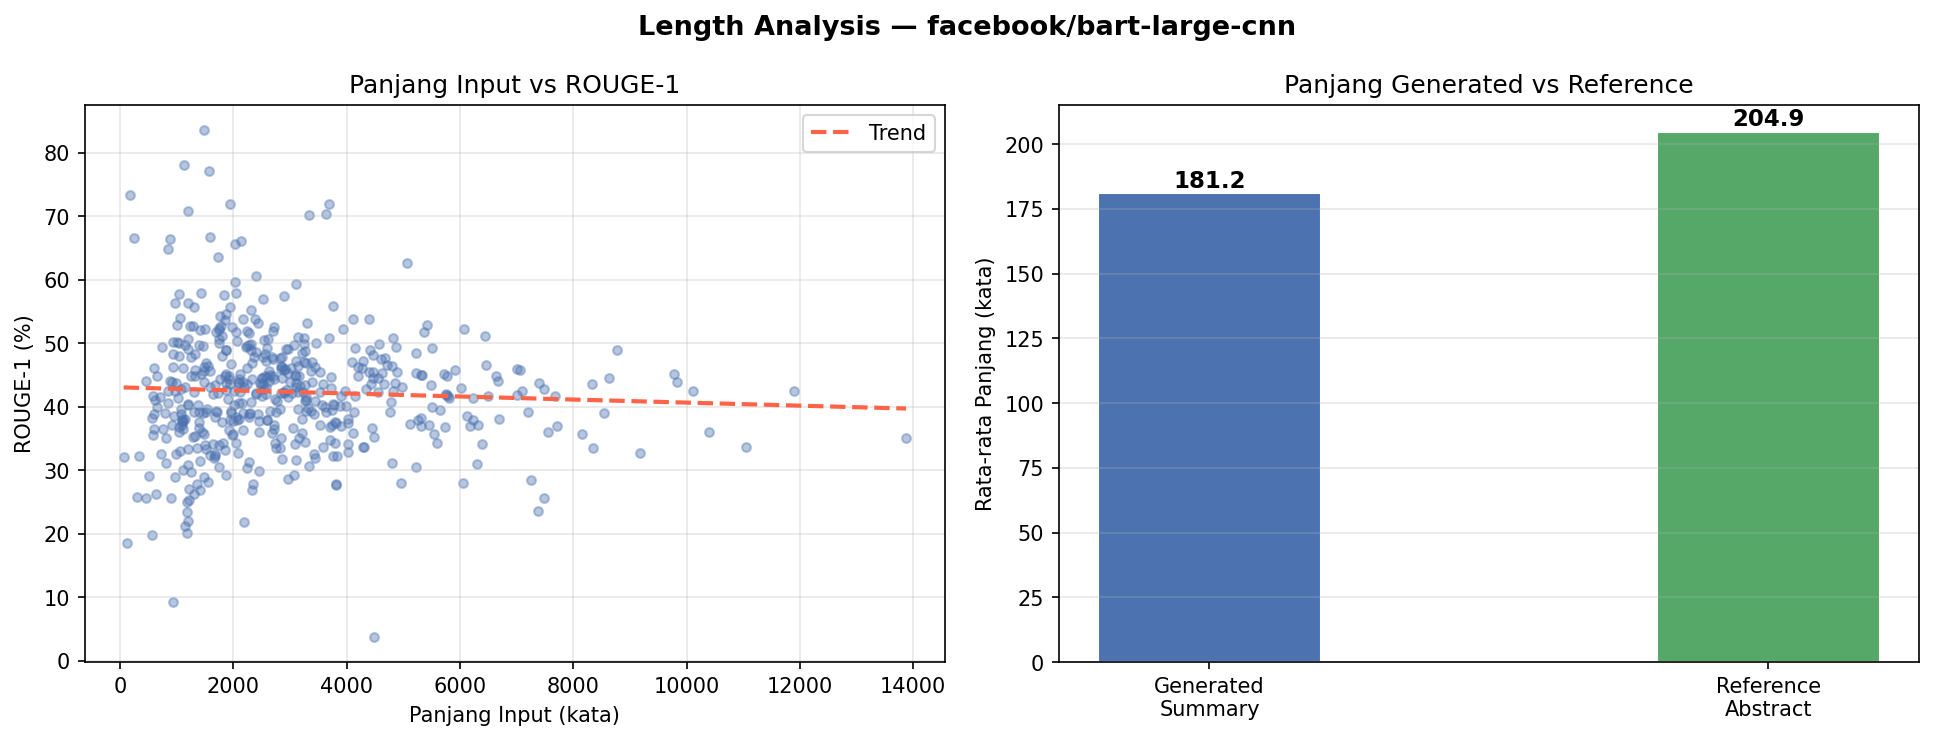


📊 Rouge Bar Hist


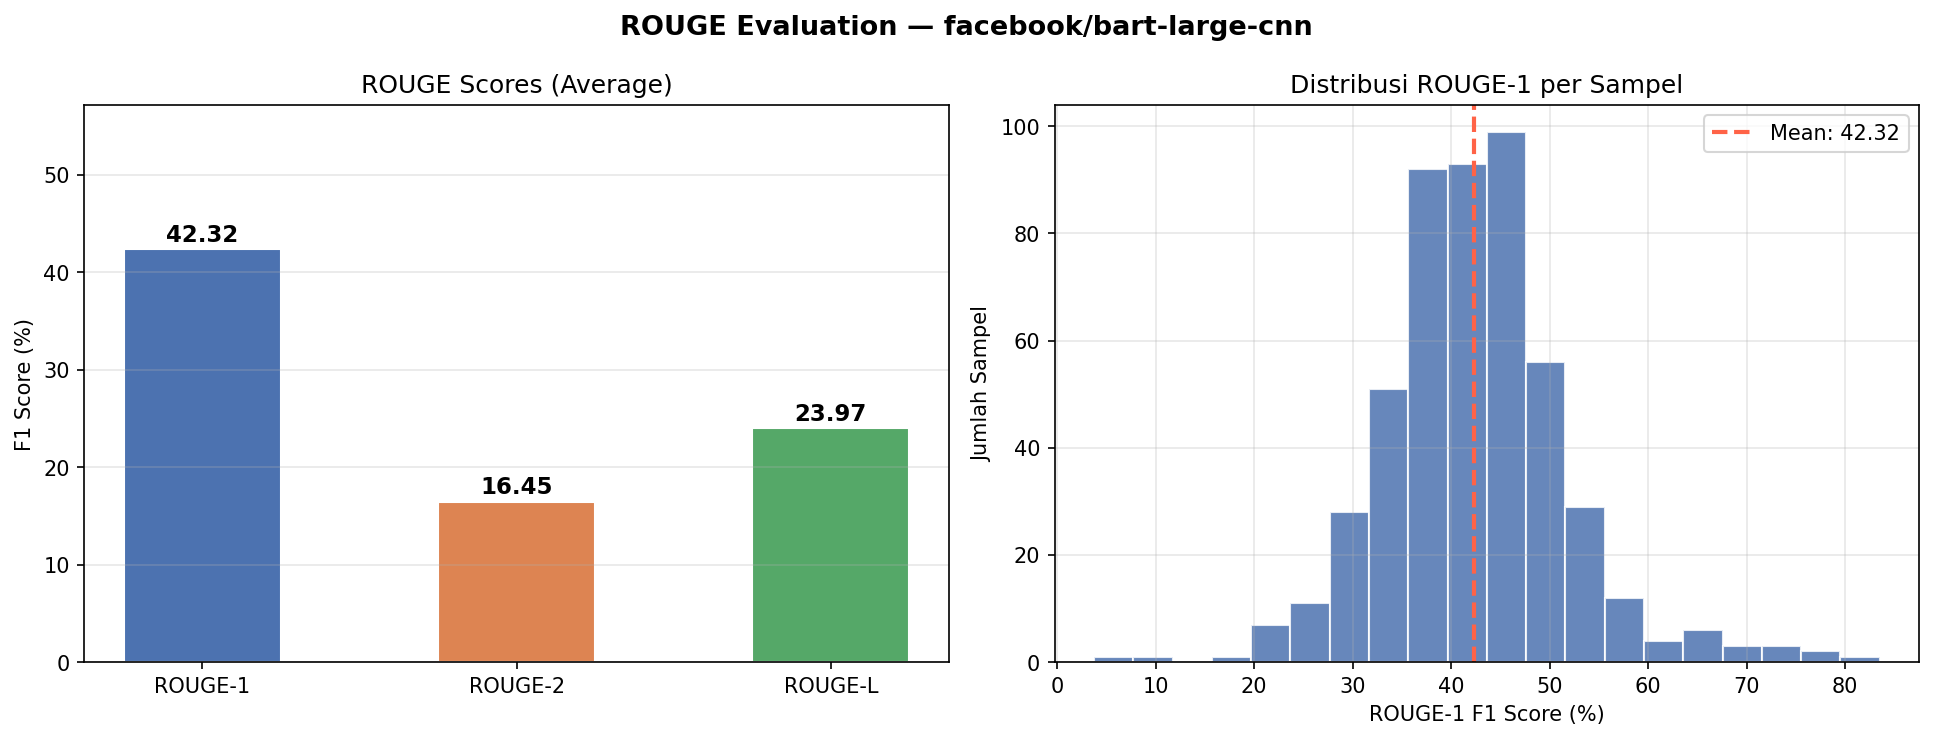


📊 Rouge Boxplot


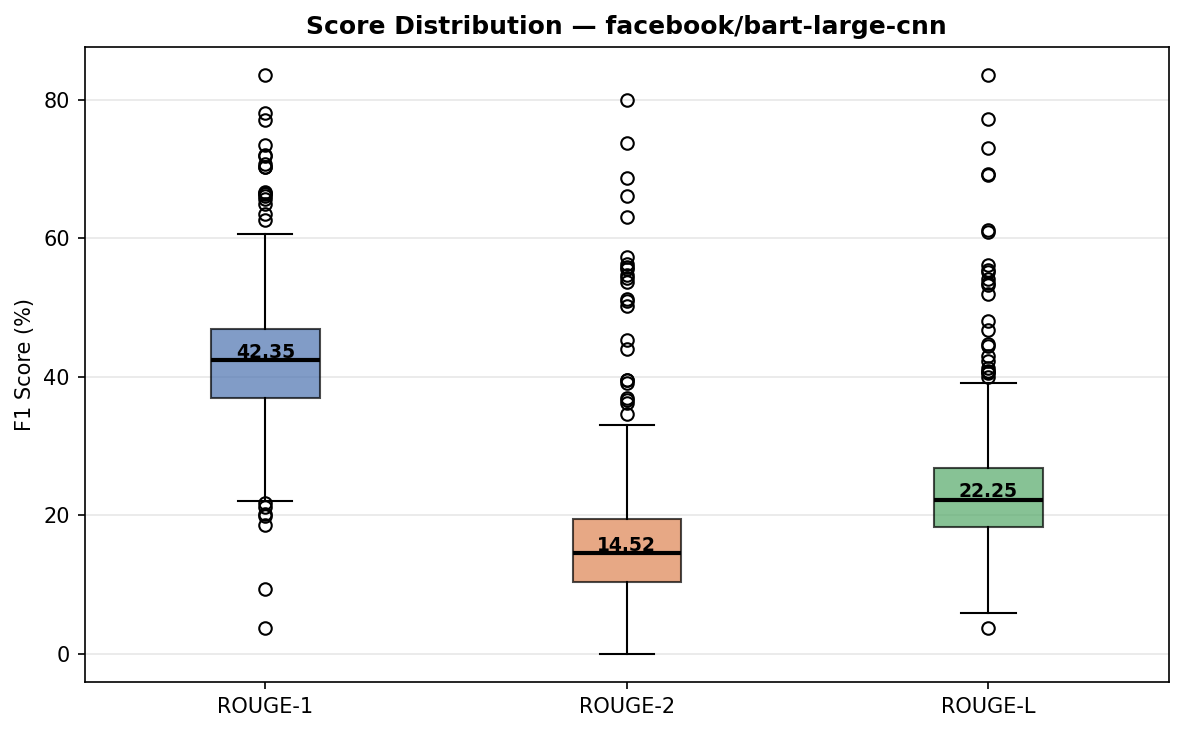


📊 Training Curves


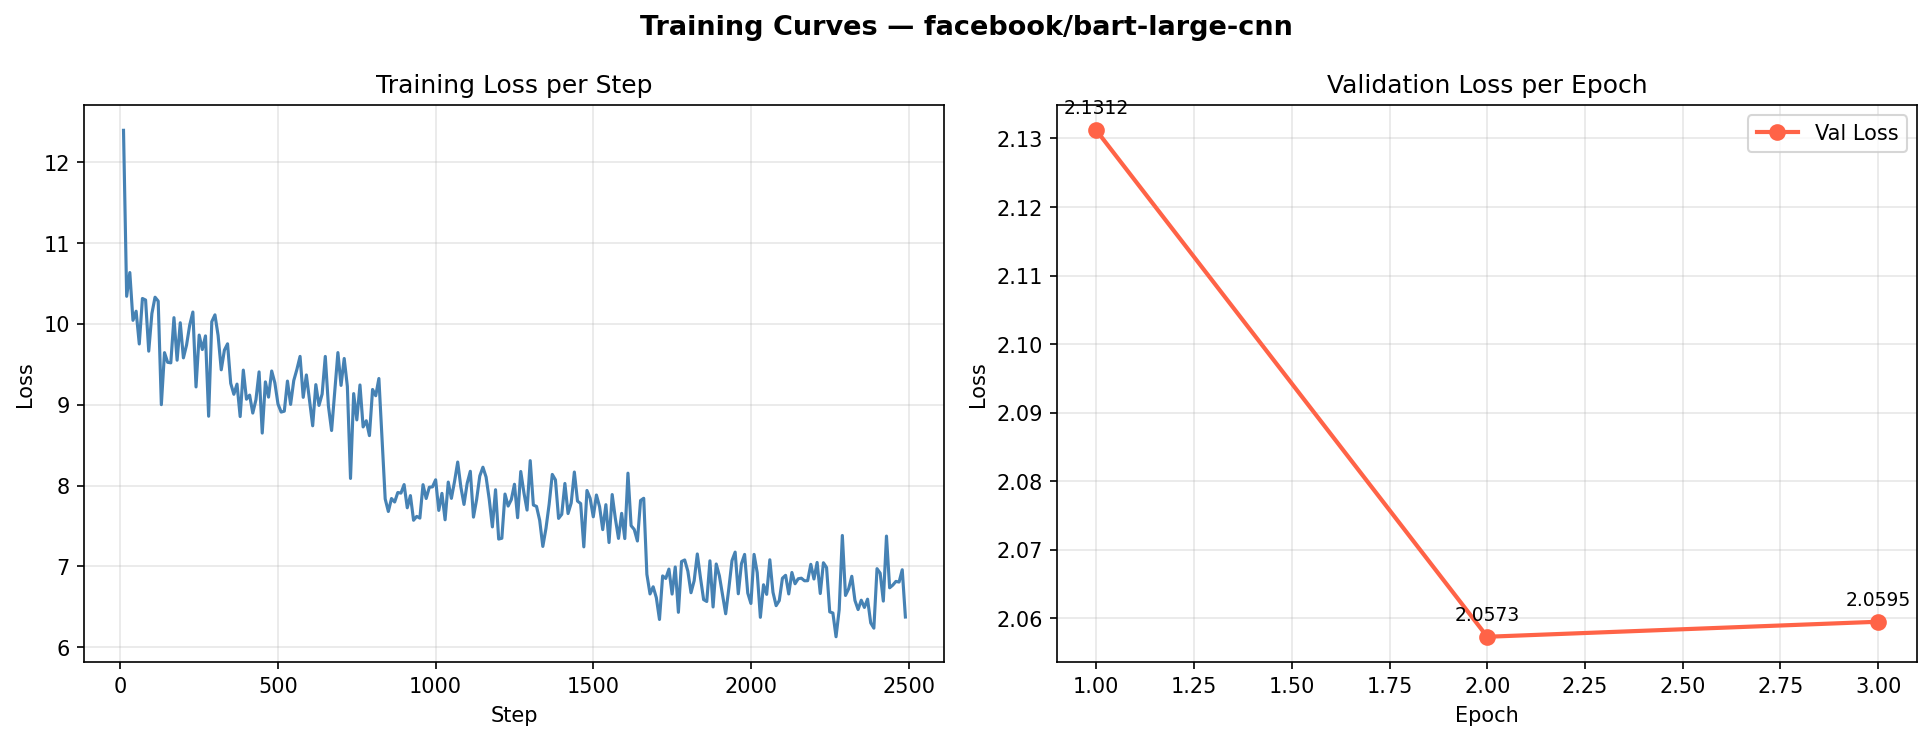

In [28]:
# --- Cell 29: Tampilkan Semua Visualisasi di Notebook ---
from IPython.display import display, Image
import glob

# ── Tampilkan semua visualisasi ──
viz_files = sorted(glob.glob('./viz_*.png'))

print(f"Total visualisasi: {len(viz_files)}")
print("=" * 50)

for f in viz_files:
    name = f.replace('./viz_', '').replace('.png', '').replace('_', ' ').title()
    print(f"\n📊 {name}")
    display(Image(filename=f, width=900))

In [29]:
# --- Cell Baru: Interaktif Testing / Inferensi Model ---

# 1. Masukkan teks artikel ilmiah yang ingin kamu uji di sini
input_teks_uji = """
[Tempel atau ketik teks artikel/paper PubMed yang ingin kamu ringkas di sini. 
Contoh: Acute respiratory distress syndrome (ARDS) remains a significant cause of morbidity... 
kamu bisa mengambil potongan teks dari data test atau paper baru.]
"""

# 2. Cek apakah teks kosong atau masih berupa placeholder
if input_teks_uji.strip() == "" or "[Tempel atau ketik" in input_teks_uji:
    print("⚠️ Silakan masukkan teks artikel ilmiah terlebih dahulu pada variabel 'input_teks_uji'!")
else:
    print("⏳ Sedang memproses teks dan melakukan ringkasan dengan BART...")
    print("-" * 60)
    
    # 3. Jalankan fungsi cleaning & normalization (menggunakan fungsi clean_text dari Cell 8)
    teks_bersih = clean_text(input_teks_uji)
    
    # 4. Tokenisasi input teks (menggunakan tokenizer_inf dari Cell 16)
    inputs = tokenizer_inf(
        teks_bersih,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt"
    ).to(device)
    
    # 5. Generate summary dengan parameter yang optimal (menggunakan model_inf dari Cell 16)
    import torch
    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=256,            # Panjang maksimal summary sesuai proposal
            min_length=50,             # Panjang minimal summary agar tetap informatif
            no_repeat_ngram_size=3,    # Menghindari pengulangan frasa yang sama
            num_beams=4,               # Beam search untuk hasil generasi yang lebih baik
            early_stopping=True
        )
    
    # 6. Decode token hasil generasi menjadi teks biasa
    hasil_ringkasan = tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)
    
    # 7. Tampilkan Hasil
    print("\n📝 [TEKS INPUT (100 Kata Pertama)]:")
    print(" ".join(teks_bersih.split()[:100]) + "...")
    print(f"\n📊 [PANJANG INPUT]: {len(teks_bersih.split())} kata")
    
    print("\n" + "="*60)
    print("✨ [HASIL RINGKASAN MODEL BART]:")
    print("="*60)
    print(hasil_ringkasan)
    print("-" * 60)
    print(f"📊 [PANJANG RINGKASAN]: {len(hasil_ringkasan.split())} kata")

⚠️ Silakan masukkan teks artikel ilmiah terlebih dahulu pada variabel 'input_teks_uji'!


In [30]:
# --- Cell Baru: Interaktif Testing / Inferensi Model ---

# 1. Masukkan teks artikel ilmiah yang ingin kamu uji di sini
input_teks_uji = """
The long-term sequelae of coronavirus disease 2019 (COVID-19), commonly referred to as 'long COVID' or post-acute sequelae of SARS-CoV-2 infection (PASC), have emerged as a significant global public health challenge. While the acute phase of COVID-19 primarily targets the respiratory system, long COVID is characterized by a multisystemic manifestation that persists for weeks, months, or even years after the initial infection. Clinical observations indicate that patients frequently report chronic fatigue, cognitive impairment often described as 'brain fog', persistent dyspnea, tachycardia, and widespread musculoskeletal pain. 

The underlying pathophysiology of long COVID remains partially understood, with several competing and overlapping hypotheses being investigated. These include the persistence of viral reservoirs in specific tissues, incomplete viral clearance, autoimmune reactivation driven by molecular mimicry, microvascular endothelial dysfunction, and chronic systemic inflammation mediated by unresolved cytokine elevation. Advanced imaging and biomarkers have shown subclinical organ damage in the heart, lungs, and brain of individuals with prolonged symptoms, even those who experienced mild acute illness.

Diagnostic approaches currently rely on comprehensive clinical evaluation, as there is no single definitive biomarker for long COVID. Management strategies are predominantly multidisciplinary, focusing on symptomatic relief, gradual physical rehabilitation, and psychological support. Clinical trials are currently underway to evaluate the efficacy of antivirals, anti-inflammatory agents, and immunomodulators in mitigating these prolonged symptoms. Understanding the exact mechanisms is crucial for developing targeted therapeutic interventions and reducing the long-term burden on healthcare systems globally.
"""

In [31]:
# 2. Cek apakah teks kosong atau masih berupa placeholder
if input_teks_uji.strip() == "" or "[Tempel atau ketik" in input_teks_uji:
    print("⚠️ Silakan masukkan teks artikel ilmiah terlebih dahulu pada variabel 'input_teks_uji'!")
else:
    print("⏳ Sedang memproses teks dan melakukan ringkasan dengan BART...")
    print("-" * 60)
    
    # 3. Jalankan fungsi cleaning & normalization (menggunakan fungsi clean_text dari Cell 8)
    teks_bersih = clean_text(input_teks_uji)
    
    # 4. Tokenisasi input teks (menggunakan tokenizer_inf dari Cell 16)
    inputs = tokenizer_inf(
        teks_bersih,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt"
    ).to(device)
    
    # 5. Generate summary dengan parameter yang optimal (menggunakan model_inf dari Cell 16)
    import torch
    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=256,            # Panjang maksimal summary sesuai proposal
            min_length=50,             # Panjang minimal summary agar tetap informatif
            no_repeat_ngram_size=3,    # Menghindari pengulangan frasa yang sama
            num_beams=4,               # Beam search untuk hasil generasi yang lebih baik
            early_stopping=True
        )
    
    # 6. Decode token hasil generasi menjadi teks biasa
    hasil_ringkasan = tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)
    
    # 7. Tampilkan Hasil
    print("\n📝 [TEKS INPUT (100 Kata Pertama)]:")
    print(" ".join(teks_bersih.split()[:100]) + "...")
    print(f"\n📊 [PANJANG INPUT]: {len(teks_bersih.split())} kata")
    
    print("\n" + "="*60)
    print("✨ [HASIL RINGKASAN MODEL BART]:")
    print("="*60)
    print(hasil_ringkasan)
    print("-" * 60)
    print(f"📊 [PANJANG RINGKASAN]: {len(hasil_ringkasan.split())} kata")

⏳ Sedang memproses teks dan melakukan ringkasan dengan BART...
------------------------------------------------------------

📝 [TEKS INPUT (100 Kata Pertama)]:
The long-term sequelae of coronavirus disease 2019 (COVID-19), commonly referred to as 'long COVID' or post-acute sequelae of SARS-CoV-2 infection (PASC), have emerged as a significant global public health challenge. While the acute phase of COVID-19 primarily targets the respiratory system, long COVID is characterized by a multisystemic manifestation that persists for weeks, months, or even years after the initial infection. Clinical observations indicate that patients frequently report chronic fatigue, cognitive impairment often described as 'brain fog', persistent dyspnea, tachycardia, and widespread musculoskeletal pain. The underlying pathophysiology of long COVID remains partially understood, with several competing and overlapping hypotheses being...

📊 [PANJANG INPUT]: 232 kata

✨ [HASIL RINGKASAN MODEL BART]:
long-term s